In [2]:
print("teste")

teste


# Projeto 2 — Aprendizado de Máquina: Olist
**Previsão de Tempo de Entrega de Pedidos (Regressão)**

| Campo | Detalhe |
|---|---|
| **Autores** | Kaike Brito Leitão · Enrico Santos Navajas · Mario · Pedro Chaves · Ian Santos · Luiz Chaves |
| **Disciplina** | T326 — Ciência dos Dados · Prof. Caio Ponte · Turma 16/17 |
| **Variável alvo** | `dias_entrega` — dias corridos entre compra e entrega ao cliente |
| **Tipo de problema** | Regressão supervisionada |

---

## Checklist de Requisitos

| # | Seção | Requisito (PDF) | Status |
|---|---|---|---|
| 1–4 | Seção 0–1 | Definição do problema, contexto Olist, tabelas e impacto | ✅ |
| 5–9 | Seção 2–5 | Feature engineering, limpeza, imputação, scaler, encoding | ✅ |
| 10–13 | Seção 4 | Distribuição, outliers, correlação, mapa geográfico | ✅ |
| 14–16 | Seção 5–7 | Split treino/teste, 5 modelos, RandomizedSearchCV | ✅ |
| 17–20 | Seção 6–9 | RMSE/MAE/R², benchmark, melhorias, conclusão | ✅ |

---

## Diagrama de Entidade-Relacionamento (ERD)

> A tabela `orders` é o hub central — todas as demais se conectam a ela por `order_id`.

```mermaid
erDiagram
    CUSTOMERS {
        string customer_id PK
        string customer_unique_id
        string customer_zip_code_prefix FK
        string customer_city
        string customer_state
    }
    ORDERS {
        string order_id PK
        string customer_id FK
        string order_status
        datetime order_purchase_timestamp
        datetime order_approved_at
        datetime order_delivered_carrier_date
        datetime order_delivered_customer_date
        datetime order_estimated_delivery_date
    }
    ORDER_ITEMS {
        string order_id PK,FK
        int order_item_id PK
        string product_id FK
        string seller_id FK
        datetime shipping_limit_date
        float price
        float freight_value
    }
    PRODUCTS {
        string product_id PK
        string product_category_name FK
        int product_name_lenght
        int product_description_lenght
        int product_photos_qty
        float product_weight_g
        float product_length_cm
        float product_height_cm
        float product_width_cm
    }
    SELLERS {
        string seller_id PK
        string seller_zip_code_prefix FK
        string seller_city
        string seller_state
    }
    ORDER_PAYMENTS {
        string order_id PK,FK
        int payment_sequential PK
        string payment_type
        int payment_installments
        float payment_value
    }
    ORDER_REVIEWS {
        string review_id PK
        string order_id FK
        int review_score
        string review_comment_title
        string review_comment_message
        datetime review_creation_date
        datetime review_answer_timestamp
    }
    GEOLOCATION {
        string geolocation_zip_code_prefix PK
        float geolocation_lat
        float geolocation_lng
        string geolocation_city
        string geolocation_state
    }
    TRANSLATION {
        string product_category_name PK
        string product_category_name_english
    }
    CUSTOMERS ||--o{ ORDERS : "realiza_pedido"
    ORDERS ||--|{ ORDER_ITEMS : "contem_itens"
    ORDERS ||--|{ ORDER_PAYMENTS : "possui_pagamentos"
    ORDERS ||--o{ ORDER_REVIEWS : "recebe_avaliacao"
    PRODUCTS ||--o{ ORDER_ITEMS : "compoe"
    SELLERS ||--o{ ORDER_ITEMS : "fornece"
    GEOLOCATION ||--o{ CUSTOMERS : "localiza_cliente"
    GEOLOCATION ||--o{ SELLERS : "localiza_vendedor"
    TRANSLATION ||--o{ PRODUCTS : "traduz_categoria"
```


---
## Seção 0 — Definição do Problema

**Contexto:** A Olist conecta pequenos lojistas a grandes marketplaces brasileiros.
Com operações em 27 estados, enfrenta o desafio de prever o prazo de entrega
no momento da compra — antes de qualquer rastreamento.

**Variável alvo:** `dias_entrega = (data_entrega − data_compra).days`

**Impacto de negócio:**
- Logística proativa: identificar pedidos de alto risco antes do atraso
- SLAs mais precisos reduzem cancelamentos e reclamações
- Precificação de frete diferenciada por rota e peso


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, logging
from pathlib import Path
from typing import Dict, List
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

RAW          = Path("../dataframes/raw/")
OUT          = Path("../dataframes/processed/")
OUT.mkdir(exist_ok=True)
RANDOM_STATE = 42
TEST_SIZE    = 0.20
OUTLIER_P99  = 46
PALETA       = "#2563EB"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── Nota: todos os DataFrames são exibidos com display(df).
# No VS Code, o botão "Abrir no Manipulador de Dados" (Data Wrangler)
# aparece automaticamente acima de cada saída tabular.
# Atalho: clique no ícone de tabela no canto superior direito do output.
print("✅ Setup concluído")

✅ Setup concluído


---
## Seção 1 — Carregamento das Tabelas

8 tabelas do dataset público Olist (Kaggle). A tabela `orders` é o hub central.


In [4]:
def carregar_tabelas(path: Path) -> Dict[str, pd.DataFrame]:
    """Carrega os 8 CSVs do Olist. Returns: dict {nome: DataFrame}."""
    arquivos = {
        "orders":      "olist_orders_dataset.csv",
        "order_items": "olist_order_items_dataset.csv",
        "payments":    "olist_order_payments_dataset.csv",
        "products":    "olist_products_dataset.csv",
        "sellers":     "olist_sellers_dataset.csv",
        "customers":   "olist_customers_dataset.csv",
        "geolocation": "olist_geolocation_dataset.csv",
        "translation": "product_category_name_translation.csv",
    }
    dfs = {}
    for nome, arq in arquivos.items():
        dfs[nome] = pd.read_csv(path / arq)
        logger.info(f"{nome}: {dfs[nome].shape}")
    return dfs

dfs = carregar_tabelas(RAW)

# Inventário das tabelas — abrir no Data Wrangler para explorar
tabelas_info = pd.DataFrame([
    {"Tabela": k, "Linhas": v.shape[0], "Colunas": v.shape[1]}
    for k, v in dfs.items()
])
display(tabelas_info)

INFO | orders: (99441, 8)
INFO | order_items: (112650, 7)
INFO | payments: (103886, 5)
INFO | products: (32951, 9)
INFO | sellers: (3095, 4)
INFO | customers: (99441, 5)
INFO | geolocation: (1000163, 5)
INFO | translation: (71, 2)


,Tabela,Linhas,Colunas
0,orders,99441,8
1,order_items,112650,7
2,payments,103886,5
3,products,32951,9
4,sellers,3095,4
5,customers,99441,5
6,geolocation,1000163,5
7,translation,71,2


---
## Seção 2 — Engenharia de Features

38 features construídas a partir de 8 tabelas, organizadas por domínio.
Features marcadas com ★ são novas em relação ao baseline.

| Domínio | Qtd | Destaques |
|---|---|---|
| Temporais | 7 | `estimativa_prazo`, `fim_de_semana`, `periodo_dia` |
| Geográficas ★ | 13 | `dist_km` (r=+0.44), `mesma_uf` (r=−0.41), `media_dias_uf_cliente` (r=+0.46) |
| Logísticas ★ | 8 | `freight_ratio`, `avg_price_per_item`, `price_range` |
| Seller ★ | 3 | `seller_avg_delivery` (r=+0.35), `seller_std_delivery`, `seller_n_orders` |
| Produto | 5 | `product_weight_g`, `volume_cm3`, `densidade_g_cm3` ★ |
| Pagamento | 2 | `payment_type`, `payment_installments_max` |


In [5]:
REGIAO_MAP: Dict[str, str] = {
    "AC":"Norte","AM":"Norte","AP":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste",
    "PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MS":"Centro-Oeste","MT":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul",
}

def haversine_vec(lat1, lon1, lat2, lon2):
    """
    Distância geodésica (km) — Fórmula de Haversine vetorizada.
    Superiora à distância euclidiana: corrige a curvatura da Terra.
    Erro euclidiano no Brasil pode chegar a 15% em rotas longas (SP→AM).
    """
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def construir_dataset(dfs: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Integra as 8 tabelas → 1 linha por pedido entregue com 38 features."""
    orders = dfs["orders"].copy()
    for col in ["order_purchase_timestamp","order_delivered_customer_date",
                "order_estimated_delivery_date","order_approved_at","order_delivered_carrier_date"]:
        orders[col] = pd.to_datetime(orders[col])

    df = orders[orders["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
    df["dias_entrega"]      = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
    df["estimativa_prazo"]  = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days
    df["dia_semana_compra"] = df["order_purchase_timestamp"].dt.dayofweek
    df["hora_compra"]       = df["order_purchase_timestamp"].dt.hour
    df["mes_compra"]        = df["order_purchase_timestamp"].dt.month
    df["dias_ate_aprova_h"] = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
    df["fim_de_semana"]     = df["dia_semana_compra"].isin([5, 6]).astype(int)
    df["periodo_dia"]       = pd.cut(df["hora_compra"], bins=[0,6,12,18,24], labels=[0,1,2,3], right=False).astype(float)
    df = df[["order_id","customer_id","dias_entrega","estimativa_prazo",
             "dia_semana_compra","hora_compra","mes_compra","dias_ate_aprova_h","fim_de_semana","periodo_dia"]]

    items = dfs["order_items"]
    ia = items.groupby("order_id").agg(
        n_items=("order_item_id","count"), price_total=("price","sum"),
        freight_total=("freight_value","sum"), n_sellers=("seller_id","nunique"),
        price_max=("price","max"), price_min=("price","min"),
        product_id_1st=("product_id","first"), seller_id_1st=("seller_id","first"),
    ).reset_index()
    ia["price_range"]        = ia["price_max"] - ia["price_min"]
    ia["freight_ratio"]      = (ia["freight_total"] / (ia["price_total"] + 0.01)).clip(upper=5.0)
    ia["avg_price_per_item"] = ia["price_total"] / ia["n_items"]
    df = df.merge(ia.drop(columns=["price_max","price_min"]), on="order_id", how="left")

    pay = dfs["payments"]
    pa = pay.groupby("order_id").agg(
        payment_value_total=("payment_value","sum"),
        payment_installments_max=("payment_installments","max"),
    ).reset_index()
    pa = pa.merge(pay.sort_values("payment_sequential").groupby("order_id")["payment_type"].first().reset_index(), on="order_id")
    df = df.merge(pa, on="order_id", how="left")

    prod = dfs["products"].merge(dfs["translation"], on="product_category_name", how="left")
    prod["volume_cm3"]      = prod["product_length_cm"] * prod["product_height_cm"] * prod["product_width_cm"]
    prod["densidade_g_cm3"] = (prod["product_weight_g"] / prod["volume_cm3"].replace(0, np.nan)).clip(upper=10.0)
    df = df.merge(prod[["product_id","product_category_name_english","product_weight_g",
                         "volume_cm3","densidade_g_cm3","product_photos_qty"]],
                  left_on="product_id_1st", right_on="product_id", how="left")

    geo_med = dfs["geolocation"].groupby("geolocation_zip_code_prefix")[["geolocation_lat","geolocation_lng"]].median().reset_index()
    cg = dfs["customers"][["customer_id","customer_zip_code_prefix"]].merge(
        geo_med, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left"
    ).rename(columns={"geolocation_lat":"clat","geolocation_lng":"clng"})
    sg = dfs["sellers"][["seller_id","seller_zip_code_prefix"]].merge(
        geo_med, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left"
    ).rename(columns={"geolocation_lat":"slat","geolocation_lng":"slng"})

    df = df.merge(cg[["customer_id","clat","clng"]], on="customer_id", how="left")
    df = df.merge(sg[["seller_id","slat","slng"]], left_on="seller_id_1st", right_on="seller_id", how="left")

    valid = df["clat"].notna() & df["slat"].notna() & df["clat"].between(-35,6) & df["slat"].between(-35,6)
    df["dist_km"] = np.nan
    df.loc[valid, "dist_km"] = haversine_vec(df.loc[valid,"clat"].values, df.loc[valid,"clng"].values,
                                              df.loc[valid,"slat"].values, df.loc[valid,"slng"].values)
    df["delta_lat"] = df["clat"] - df["slat"]
    df["delta_lng"] = df["clng"] - df["slng"]
    df = df.rename(columns={"clat":"geolocation_lat","clng":"geolocation_lng"})
    df["faixa_dist_km"] = pd.cut(df["dist_km"], bins=[0,100,300,600,1000,2000,10000],
                                 labels=[0,1,2,3,4,5], right=False).astype(float)

    df = df.merge(dfs["sellers"][["seller_id","seller_state"]], left_on="seller_id_1st", right_on="seller_id", how="left", suffixes=("","_dup"))
    df = df.merge(dfs["customers"][["customer_id","customer_state","customer_zip_code_prefix"]], on="customer_id", how="left")
    df["mesma_uf"]        = (df["customer_state"] == df["seller_state"]).astype(int)
    df["regiao_cliente"]  = df["customer_state"].map(REGIAO_MAP)
    df["regiao_vendedor"] = df["seller_state"].map(REGIAO_MAP)
    df["mesma_regiao"]    = (df["regiao_cliente"] == df["regiao_vendedor"]).astype(int)

    ss = (df[["seller_id_1st","dias_entrega"]].groupby("seller_id_1st")
          .agg(seller_avg_delivery=("dias_entrega","mean"),
               seller_std_delivery=("dias_entrega","std"),
               seller_n_orders=("dias_entrega","count"))
          .reset_index().rename(columns={"seller_id_1st":"_sid"}))
    df = df.merge(ss, left_on="seller_id_1st", right_on="_sid", how="left")
    df["seller_std_delivery"] = df["seller_std_delivery"].fillna(df["seller_std_delivery"].median())

    uf_mean = df.groupby("customer_state")["dias_entrega"].mean().rename("media_dias_uf_cliente")
    df = df.merge(uf_mean, on="customer_state", how="left")

    df = df.drop(columns=["product_id","seller_id","seller_id_dup","_sid","product_id_1st",
                           "seller_id_1st","customer_zip_code_prefix","customer_id","order_id",
                           "slat","slng"], errors="ignore")
    return df.reset_index(drop=True)


df_raw = construir_dataset(dfs)
print(f"Dataset bruto: {df_raw.shape}")

# Abrir no Data Wrangler para inspecionar as features geradas
display(df_raw.head(5))

Dataset bruto: (96470, 39)


,dias_entrega,estimativa_prazo,dia_semana_compra,hora_compra,mes_compra,dias_ate_aprova_h,fim_de_semana,periodo_dia,n_items,price_total,...,seller_state,customer_state,mesma_uf,regiao_cliente,regiao_vendedor,mesma_regiao,seller_avg_delivery,seller_std_delivery,seller_n_orders,media_dias_uf_cliente
0,8,15,0,10,10,0.178333,0,1.0,1,29.99,...,SP,SP,1,Sudeste,Sudeste,1,7.000000,4.329561,52,8.298094
1,13,19,1,20,7,30.713889,0,3.0,1,118.70,...,SP,BA,0,Nordeste,Sudeste,0,6.298077,4.033548,104,18.866400
2,9,26,2,8,8,0.276111,0,1.0,1,159.90,...,SP,GO,0,Centro-Oeste,Sudeste,0,14.638317,9.539199,1117,15.150741
3,13,26,5,19,11,0.298056,1,3.0,1,45.00,...,MG,RN,0,Nordeste,Sudeste,0,10.893333,7.261322,150,18.824895
4,2,12,1,21,2,1.030556,0,3.0,1,19.90,...,SP,SP,1,Sudeste,Sudeste,1,13.233871,13.657905,124,8.298094


In [6]:
print(df_raw.columns)

Index(['dias_entrega', 'estimativa_prazo', 'dia_semana_compra', 'hora_compra',
       'mes_compra', 'dias_ate_aprova_h', 'fim_de_semana', 'periodo_dia',
       'n_items', 'price_total', 'freight_total', 'n_sellers', 'price_range',
       'freight_ratio', 'avg_price_per_item', 'payment_value_total',
       'payment_installments_max', 'payment_type',
       'product_category_name_english', 'product_weight_g', 'volume_cm3',
       'densidade_g_cm3', 'product_photos_qty', 'geolocation_lat',
       'geolocation_lng', 'dist_km', 'delta_lat', 'delta_lng', 'faixa_dist_km',
       'seller_state', 'customer_state', 'mesma_uf', 'regiao_cliente',
       'regiao_vendedor', 'mesma_regiao', 'seller_avg_delivery',
       'seller_std_delivery', 'seller_n_orders', 'media_dias_uf_cliente'],
      dtype='str')


---
## Seção 3 — Limpeza dos Dados

| Regra | Critério | Justificativa |
|---|---|---|
| Target nulo | `dias_entrega IS NULL` | Erro de sistema |
| Entrega impossível | `dias_entrega <= 0` | Timestamp corrompido |
| Outlier extremo | `dias_entrega > P99 = 46d` | Casos excepcionais (greves, desastres) |
| Prazo inválido | `estimativa_prazo <= 0` | Dado corrompido |


In [7]:
def limpar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Remove ruídos e outliers extremos do target. Preserva 99% dos dados reais."""
    n = len(df)
    df = df.dropna(subset=["dias_entrega"])
    df = df[df["dias_entrega"] > 0]
    df = df[df["dias_entrega"] <= OUTLIER_P99]
    df = df.dropna(subset=["estimativa_prazo"])
    df = df[df["estimativa_prazo"] > 0]
    logger.info(f"Limpeza: {n:,} → {len(df):,} linhas ({n-len(df):,} removidas)")
    return df.reset_index(drop=True)

df_clean = limpar_dataset(df_raw)

# Estatísticas do target — Data Wrangler para exploração interativa
target_stats = df_clean["dias_entrega"].describe().round(2).to_frame().T
target_stats.insert(0, "skewness", round(df_clean["dias_entrega"].skew(), 3))
target_stats.insert(0, "n_pedidos", len(df_clean))
display(target_stats)

# Nulos por feature com estratégia de tratamento
nulos = df_clean.isnull().sum()
nulos = nulos[nulos > 0].reset_index()
nulos.columns = ["feature", "n_nulos"]
nulos["pct_%"] = (nulos["n_nulos"] / len(df_clean) * 100).round(3)
nulos["tratamento"] = nulos["feature"].apply(lambda f:
    "SimpleImputer(most_frequent) + OrdinalEncoder"
    if f in {"product_category_name_english","regiao_cliente","regiao_vendedor"}
    else "KNNImputer(n_neighbors=5) + StandardScaler")
display(nulos)

# Exportar dataset enriquecido
df_clean.to_csv(OUT / "olist_dataset_enriquecido.csv", index=False)
logger.info(f"Dataset exportado: {df_clean.shape}")

INFO | Limpeza: 96,470 → 95,577 linhas (893 removidas)


,n_pedidos,skewness,count,mean,std,min,25%,50%,75%,max
dias_entrega,95577,1.429,95577.0,11.62,7.81,1.0,6.0,10.0,15.0,46.0


,feature,n_nulos,pct_%,tratamento
0,dias_ate_aprova_h,14,0.015,KNNImputer(n_neighbors=5) + StandardScaler
1,product_category_name_english,1370,1.433,SimpleImputer(most_frequent) + OrdinalEncoder
2,product_weight_g,16,0.017,KNNImputer(n_neighbors=5) + StandardScaler
3,volume_cm3,16,0.017,KNNImputer(n_neighbors=5) + StandardScaler
4,densidade_g_cm3,16,0.017,KNNImputer(n_neighbors=5) + StandardScaler
5,product_photos_qty,1351,1.414,KNNImputer(n_neighbors=5) + StandardScaler
6,geolocation_lat,258,0.270,KNNImputer(n_neighbors=5) + StandardScaler
7,geolocation_lng,258,0.270,KNNImputer(n_neighbors=5) + StandardScaler
8,dist_km,475,0.497,KNNImputer(n_neighbors=5) + StandardScaler
9,delta_lat,471,0.493,KNNImputer(n_neighbors=5) + StandardScaler


INFO | Dataset exportado: (95577, 39)


---
## Seção 4 — Análise Exploratória de Dados (EDA)

9 análises orientadas por perguntas de negócio.


### 4.1 Distribuição do Target
**Pergunta:** como se distribui o tempo de entrega?
Skewness = 1,43 → assimetria positiva. A maioria chega em ~10 dias; cauda longa no Norte/Nordeste.


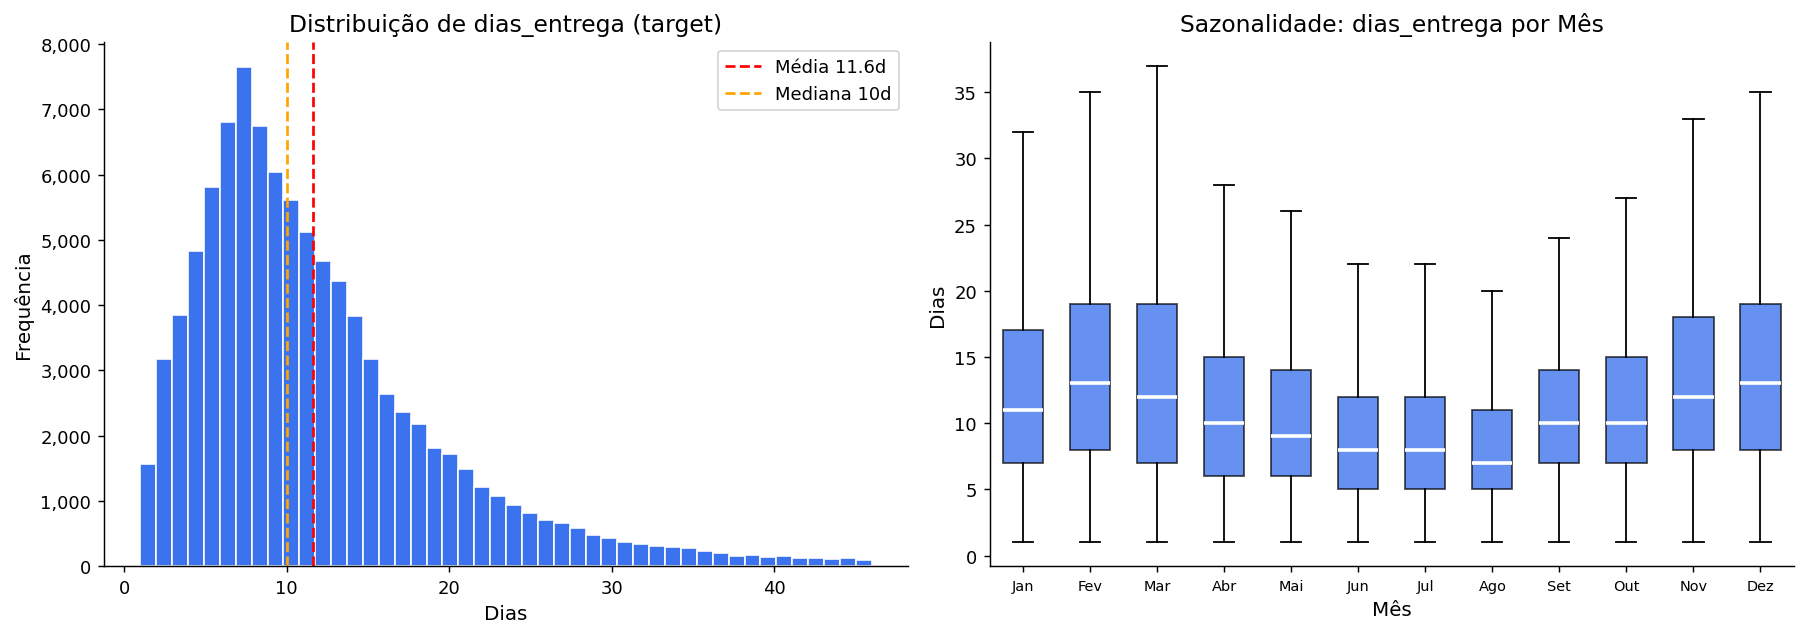

,mes_compra,media,mediana,std,n_pedidos
0,Jan,12.83,11.0,8.11,7719
1,Fev,14.67,13.0,8.92,8028
2,Mar,14.00,12.0,9.34,9374
3,Abr,11.45,10.0,7.57,9031
4,Mai,10.70,9.0,7.02,10255
5,Jun,9.46,8.0,6.06,9190
6,Jul,9.33,8.0,6.11,9987
7,Ago,8.59,7.0,5.61,10534
8,Set,11.17,10.0,6.55,4132
9,Out,11.57,10.0,7.11,4715


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean["dias_entrega"], bins=46, color=PALETA, edgecolor="white", alpha=0.9)
axes[0].axvline(df_clean["dias_entrega"].mean(), color="red", ls="--", lw=1.5,
                label=f"Média {df_clean['dias_entrega'].mean():.1f}d")
axes[0].axvline(df_clean["dias_entrega"].median(), color="orange", ls="--", lw=1.5,
                label=f"Mediana {df_clean['dias_entrega'].median():.0f}d")
axes[0].set_title("Distribuição de dias_entrega (target)")
axes[0].set_xlabel("Dias"); axes[0].set_ylabel("Frequência")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[0].legend()

meses = sorted(df_clean["mes_compra"].unique())
axes[1].boxplot([df_clean[df_clean["mes_compra"]==m]["dias_entrega"].values for m in meses],
                positions=meses, widths=0.6, patch_artist=True, showfliers=False,
                boxprops=dict(facecolor=PALETA, alpha=0.7), medianprops=dict(color="white", lw=2))
axes[1].set_title("Sazonalidade: dias_entrega por Mês")
axes[1].set_xlabel("Mês"); axes[1].set_ylabel("Dias")
axes[1].set_xticks(meses)
axes[1].set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"], fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"fig1_target.png", bbox_inches="tight"); plt.show()

# Tabela de sazonalidade — Data Wrangler
mes_stats = (df_clean.groupby("mes_compra")["dias_entrega"]
             .agg(media="mean", mediana="median", std="std", n_pedidos="count").round(2).reset_index())
mes_stats["mes_compra"] = mes_stats["mes_compra"].map(
    {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"})
display(mes_stats)

### 4.2 Correlações com o Target — Top 20
**Pergunta:** quais features explicam mais o tempo de entrega?
Azul = positivo · Vermelho = negativo


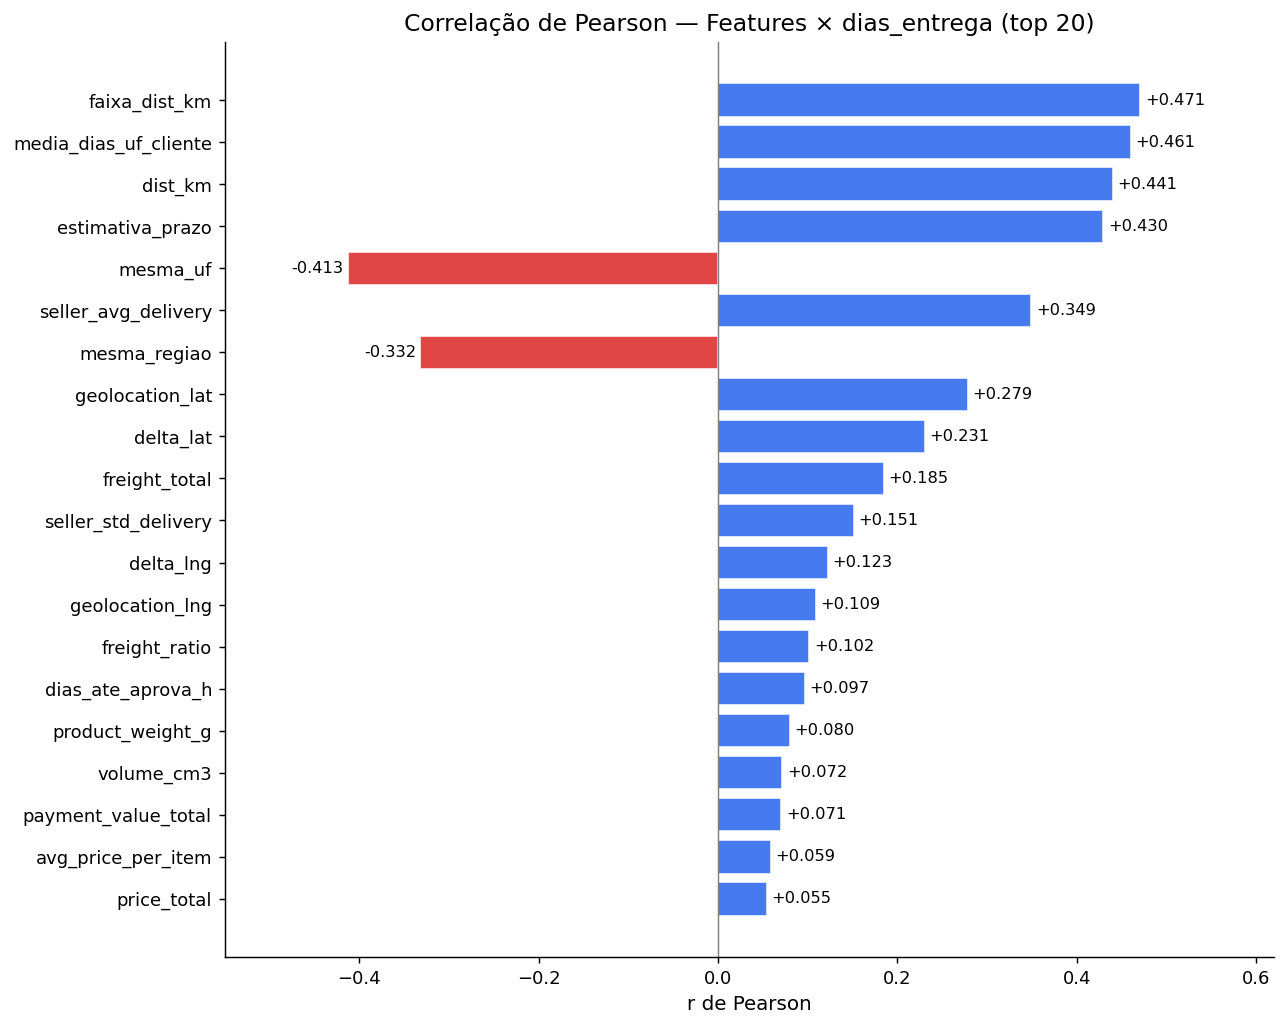

,feature,pearson_r,forca
0,faixa_dist_km,0.4711,forte +
1,media_dias_uf_cliente,0.4608,forte +
2,dist_km,0.4407,forte +
3,estimativa_prazo,0.4297,forte +
4,mesma_uf,-0.4130,forte −
5,seller_avg_delivery,0.3494,moderada
6,mesma_regiao,-0.3317,moderada
7,geolocation_lat,0.2786,moderada
8,delta_lat,0.2309,moderada
9,freight_total,0.1847,moderada


In [9]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_all = (df_clean[num_cols].corr()["dias_entrega"]
            .drop("dias_entrega").sort_values(key=abs, ascending=False).head(20))

fig, ax = plt.subplots(figsize=(10, 8))
cores_bar = ["#2563EB" if v > 0 else "#DC2626" for v in corr_all.values]
bars = ax.barh(corr_all.index[::-1], corr_all.values[::-1], color=cores_bar[::-1], edgecolor="white", alpha=0.85)
ax.axvline(0, color="gray", lw=0.8)
for bar, val in zip(bars, corr_all.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
ax.set_title("Correlação de Pearson — Features × dias_entrega (top 20)")
ax.set_xlabel("r de Pearson"); ax.set_xlim(-0.55, 0.62)
plt.tight_layout(); plt.savefig(OUT/"fig2_correlacoes.png", bbox_inches="tight"); plt.show()

# Tabela com interpretação — Data Wrangler
corr_table = (corr_all.reset_index()
              .rename(columns={"index":"feature","dias_entrega":"pearson_r"})
              .assign(pearson_r=lambda d: d["pearson_r"].round(4))
              .assign(forca=lambda d: d["pearson_r"].apply(
                  lambda r: "forte +" if r > 0.35 else ("forte −" if r < -0.35
                  else ("moderada" if abs(r) > 0.10 else "fraca")))))
display(corr_table)

### 4.3 Matriz de Correlação
**Pergunta:** existe multicolinearidade entre as features?
Nota: `faixa_dist_km` × `dist_km` (r≈0.97) — colinearidade esperada (features derivadas).


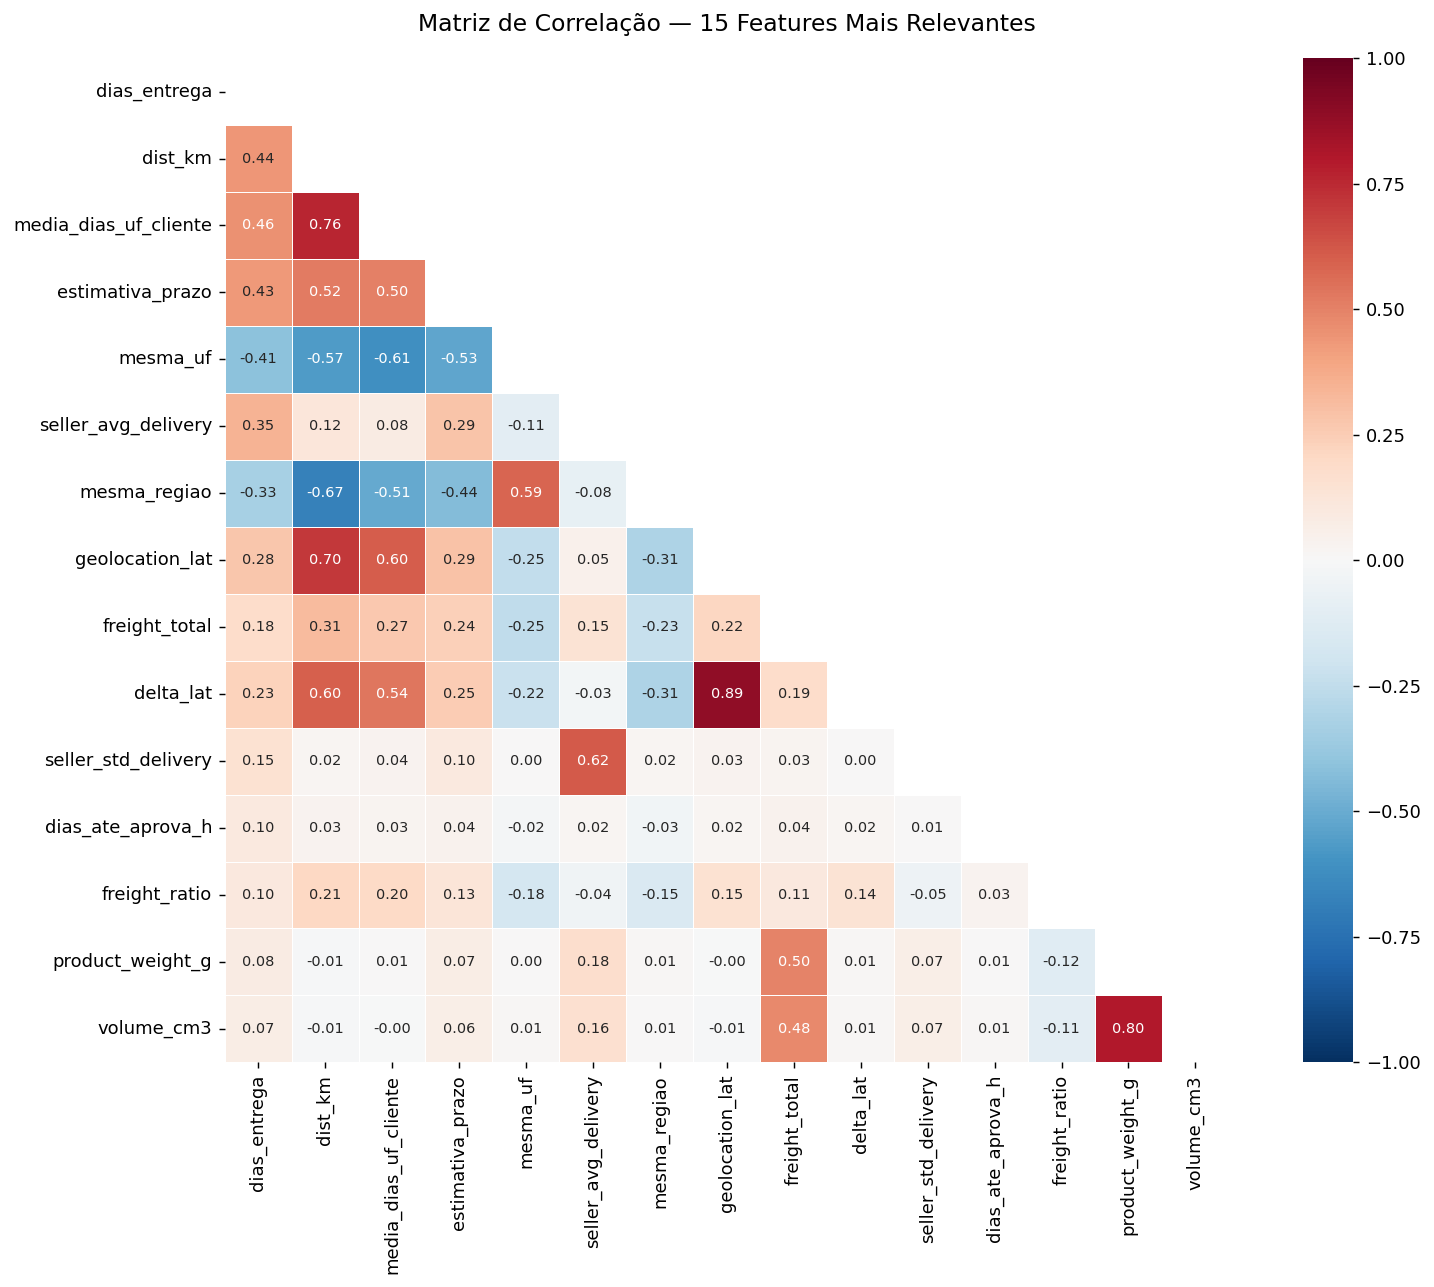

In [10]:
key_feats = ["dias_entrega","dist_km","media_dias_uf_cliente","estimativa_prazo",
             "mesma_uf","seller_avg_delivery","mesma_regiao","geolocation_lat",
             "freight_total","delta_lat","seller_std_delivery",
             "dias_ate_aprova_h","freight_ratio","product_weight_g","volume_cm3"]
corr_mat = df_clean[key_feats].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.4, annot_kws={"size":8}, ax=ax)
ax.set_title("Matriz de Correlação — 15 Features Mais Relevantes", pad=15)
plt.tight_layout(); plt.savefig(OUT/"fig3_heatmap.png", bbox_inches="tight"); plt.show()

### 4.4 Detecção de Outliers (IQR)
**Critério:** valores fora de [Q1 − 1.5×IQR, Q3 + 1.5×IQR].
Outliers NÃO são removidos das features — informam a escolha do scaler.


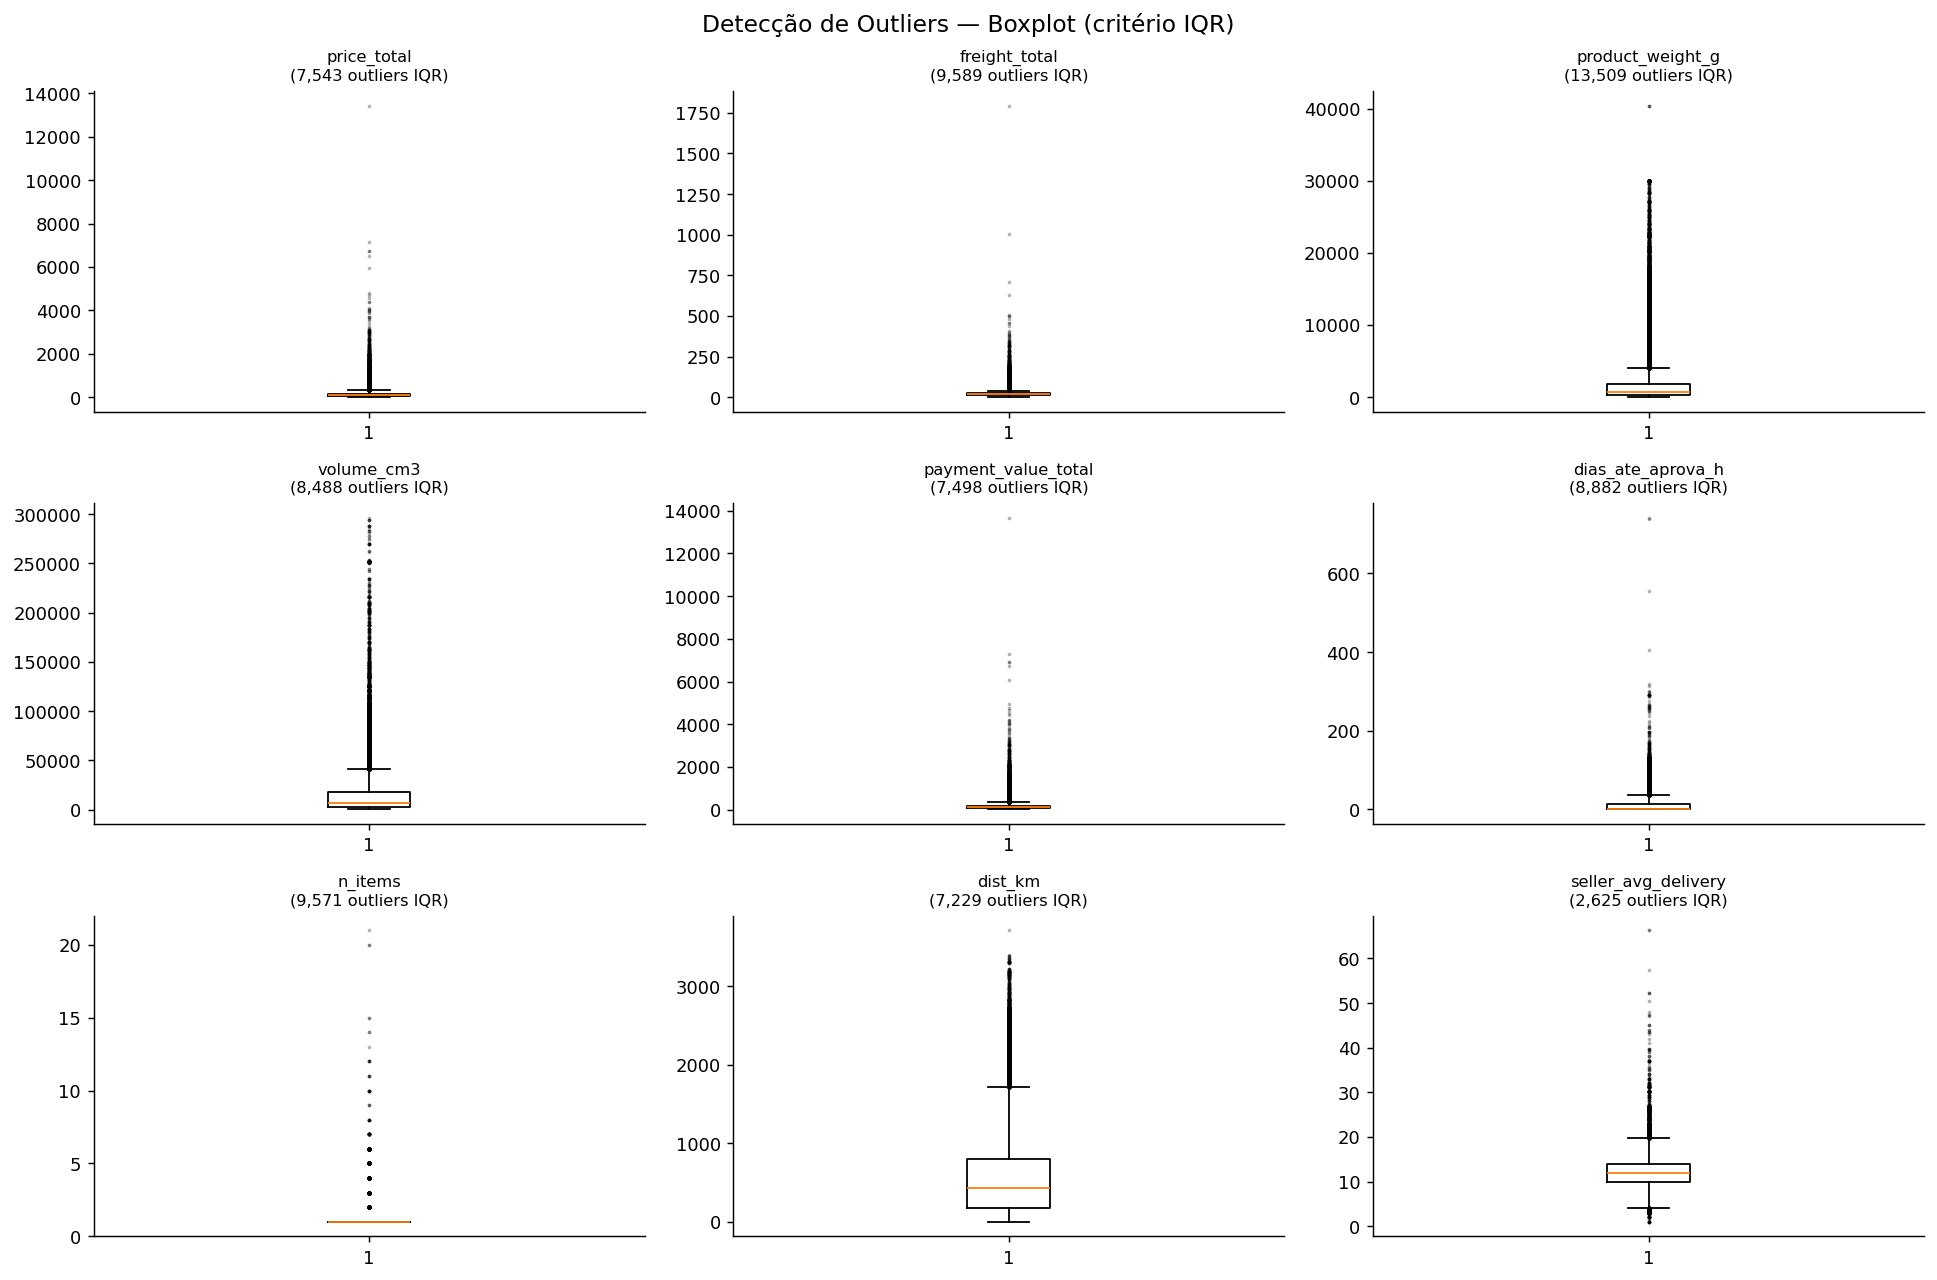

,feature,Q1,Q3,IQR,n_outliers,pct_%
0,price_total,45.90,149.90,104.00,7543,7.89
1,freight_total,13.81,23.94,10.13,9589,10.03
2,product_weight_g,300.00,1800.00,1500.00,13509,14.14
3,volume_cm3,2816.00,18040.00,15224.00,8488,8.88
4,payment_value_total,61.78,175.87,114.09,7498,7.84
5,dias_ate_aprova_h,0.22,14.48,14.27,8882,9.29
6,n_items,1.00,1.00,0.00,9571,10.01
7,dist_km,181.07,793.35,612.28,7229,7.60
8,seller_avg_delivery,9.98,13.90,3.91,2625,2.75


In [11]:
features_box = ["price_total","freight_total","product_weight_g","volume_cm3",
                "payment_value_total","dias_ate_aprova_h","n_items","dist_km","seller_avg_delivery"]
fig, axes = plt.subplots(3, 3, figsize=(15, 10)); axes = axes.flatten()
outlier_report = []
for i, col in enumerate(features_box):
    dados = df_clean[col].dropna()
    q1, q3 = dados.quantile(0.25), dados.quantile(0.75); iqr = q3 - q1
    n_out = ((dados < q1 - 1.5*iqr) | (dados > q3 + 1.5*iqr)).sum()
    axes[i].boxplot(dados, vert=True, showfliers=True,
                    flierprops=dict(marker=".", markersize=2, alpha=0.3, color="red"))
    axes[i].set_title(f"{col}\n({n_out:,} outliers IQR)", fontsize=9)
    outlier_report.append({"feature":col, "Q1":round(q1,2), "Q3":round(q3,2),
                           "IQR":round(iqr,2), "n_outliers":int(n_out),
                           "pct_%":round(n_out/len(dados)*100,2)})
plt.suptitle("Detecção de Outliers — Boxplot (critério IQR)", fontsize=13)
plt.tight_layout(); plt.savefig(OUT/"fig4_outliers.png", bbox_inches="tight"); plt.show()

# Relatório de outliers — Data Wrangler
display(pd.DataFrame(outlier_report))

### 4.5 Análise Geográfica
**AM (24,8d) demora 3× mais que SP (8,1d)** — reflexo da infraestrutura logística regional.


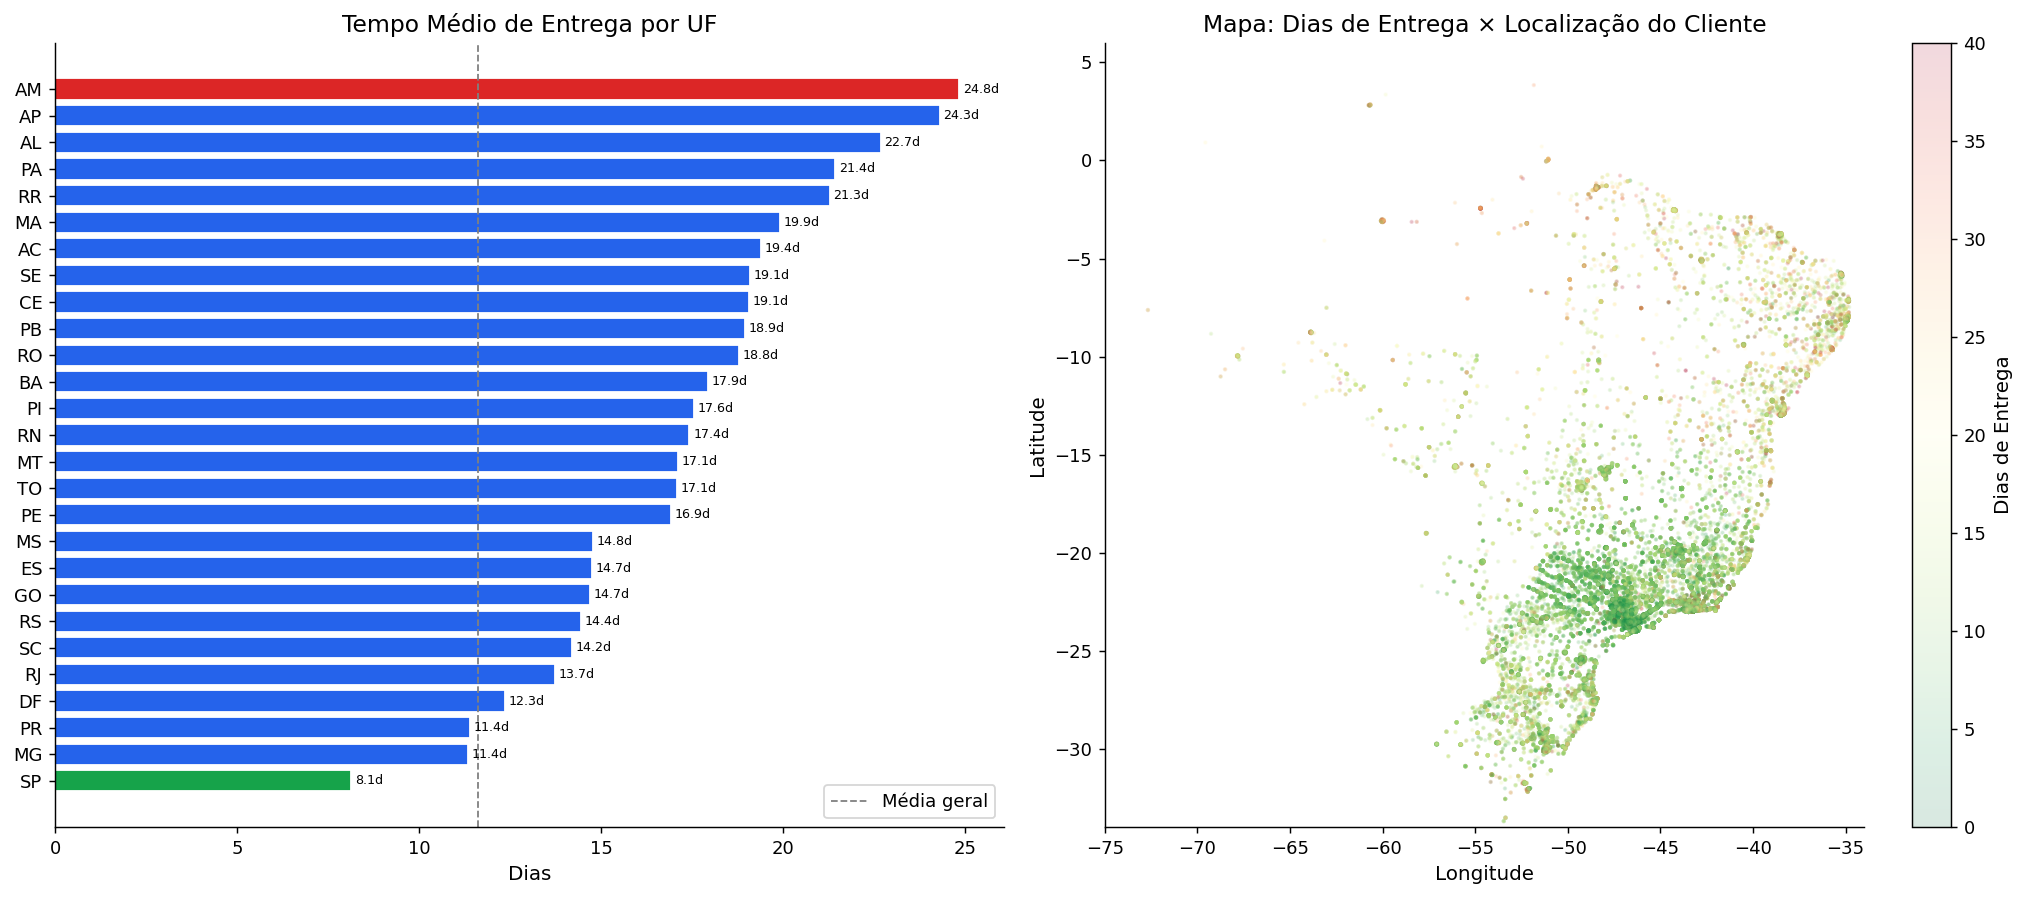

,UF,media,mediana,std,n_pedidos,regiao
0,AM,24.83,25.0,9.79,142,Norte
1,AP,24.30,24.0,8.03,66,Norte
2,AL,22.68,21.0,9.41,380,Nordeste
3,PA,21.43,20.0,9.13,899,Norte
4,RR,21.28,22.0,9.93,36,Norte
5,MA,19.91,18.0,8.17,695,Nordeste
6,AC,19.40,18.0,7.53,78,Norte
7,SE,19.08,17.0,8.77,324,Nordeste
8,CE,19.05,18.0,8.59,1231,Nordeste
9,PB,18.95,17.0,8.70,504,Nordeste


In [12]:
estado_media = df_clean.groupby("customer_state")["dias_entrega"].mean().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cores_uf = ["#DC2626" if e == estado_media.idxmax() else ("#16A34A" if e == estado_media.idxmin() else PALETA)
            for e in estado_media.index]
axes[0].barh(estado_media.index, estado_media.values, color=cores_uf, edgecolor="white")
axes[0].axvline(df_clean["dias_entrega"].mean(), color="gray", ls="--", lw=1, label="Média geral")
for i, (uf, val) in enumerate(zip(estado_media.index, estado_media.values)):
    axes[0].text(val + 0.1, i, f"{val:.1f}d", va="center", fontsize=7)
axes[0].set_title("Tempo Médio de Entrega por UF"); axes[0].set_xlabel("Dias"); axes[0].legend()

df_geo = df_clean.dropna(subset=["geolocation_lat","geolocation_lng"])
sc = axes[1].scatter(df_geo["geolocation_lng"], df_geo["geolocation_lat"],
                     c=df_geo["dias_entrega"], cmap="RdYlGn_r", alpha=0.15, s=2, vmin=0, vmax=40)
plt.colorbar(sc, ax=axes[1], label="Dias de Entrega")
axes[1].set_xlim(-75,-34); axes[1].set_ylim(-34,6)
axes[1].set_title("Mapa: Dias de Entrega × Localização do Cliente")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.tight_layout(); plt.savefig(OUT/"fig5_geo.png", bbox_inches="tight"); plt.show()

# Ranking UF completo — Data Wrangler
uf_rank = (df_clean.groupby("customer_state")["dias_entrega"]
           .agg(media="mean", mediana="median", std="std", n_pedidos="count")
           .round(2).sort_values("media", ascending=False).reset_index()
           .rename(columns={"customer_state":"UF"}))
uf_rank["regiao"] = uf_rank["UF"].map(REGIAO_MAP)
display(uf_rank)

### 4.6 Distância Haversine × Prazo
**Feature mais correlacionada:** `dist_km` com r = +0,44.
Entregas locais (<100km): 5,9d · Extremas (2000km+): 19,3d.


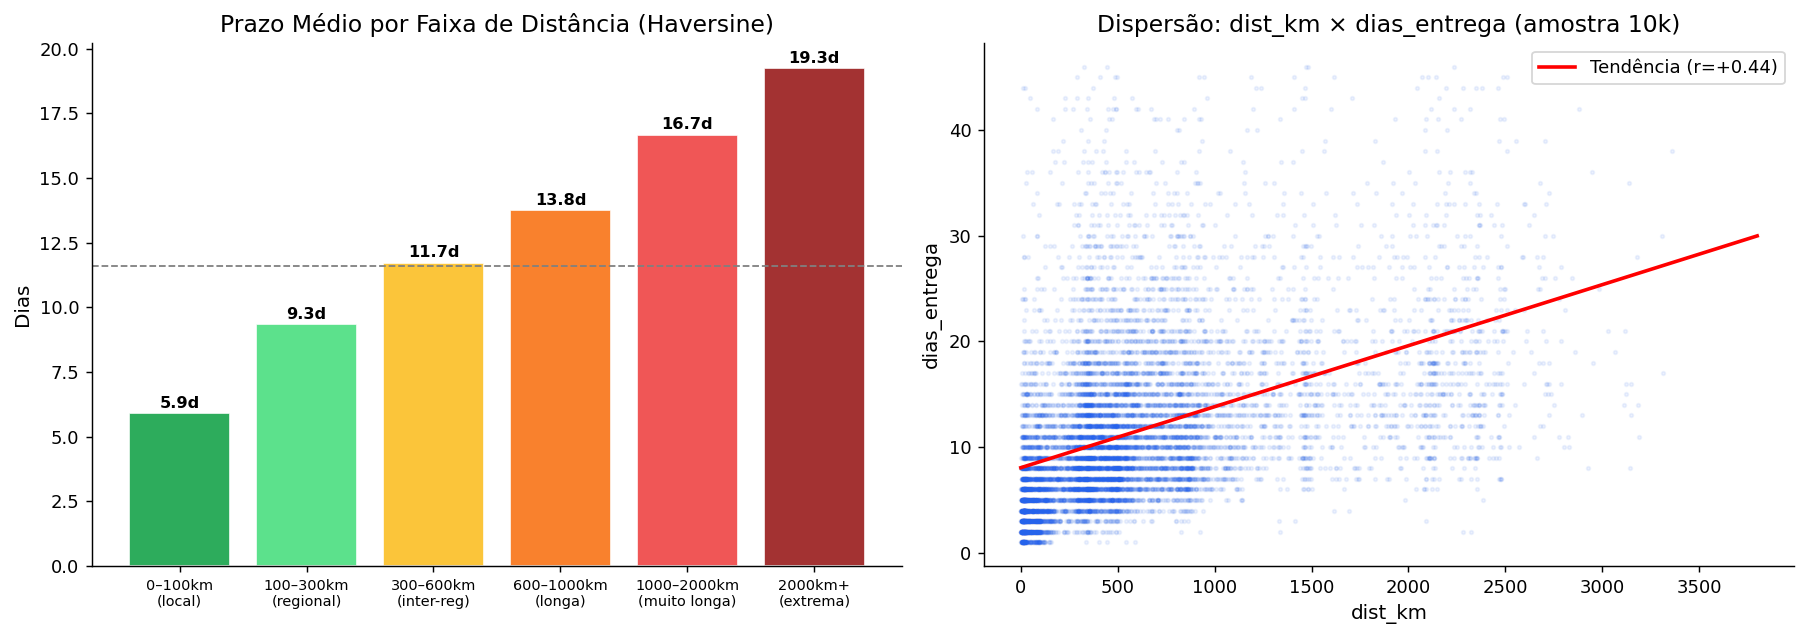

,faixa,media_dias,n_pedidos
0,0–100km\n(local),5.91,17852
1,100–300km\n(regional),9.34,13297
2,300–600km\n(inter-reg),11.73,31218
3,600–1000km\n(longa),13.75,17733
4,1000–2000km\n(muito longa),16.68,9567
5,2000km+\n(extrema),19.27,5435


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
faixa_labels = ["0–100km\n(local)","100–300km\n(regional)","300–600km\n(inter-reg)",
                "600–1000km\n(longa)","1000–2000km\n(muito longa)","2000km+\n(extrema)"]
faixa_stats = df_clean.groupby("faixa_dist_km")["dias_entrega"].agg(["mean","count"]).reset_index()
cores_f = ["#16A34A","#4ADE80","#FBBF24","#F97316","#EF4444","#991B1B"]
bars = axes[0].bar(range(len(faixa_labels)), faixa_stats["mean"].values, color=cores_f, edgecolor="white", alpha=0.9)
axes[0].set_xticks(range(len(faixa_labels))); axes[0].set_xticklabels(faixa_labels, fontsize=8)
axes[0].set_title("Prazo Médio por Faixa de Distância (Haversine)"); axes[0].set_ylabel("Dias")
axes[0].axhline(df_clean["dias_entrega"].mean(), color="gray", ls="--", lw=1)
for bar, val in zip(bars, faixa_stats["mean"].values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{val:.1f}d", ha="center", fontsize=9, fontweight="bold")

df_s = df_clean.dropna(subset=["dist_km"]).sample(10_000, random_state=42)
axes[1].scatter(df_s["dist_km"], df_s["dias_entrega"], alpha=0.08, s=4, color=PALETA)
z = np.polyfit(df_s["dist_km"], df_s["dias_entrega"], 1)
xl = np.linspace(0, 3800, 200)
axes[1].plot(xl, np.poly1d(z)(xl), color="red", lw=2, label="Tendência (r=+0.44)")
axes[1].set_xlabel("dist_km"); axes[1].set_ylabel("dias_entrega")
axes[1].set_title("Dispersão: dist_km × dias_entrega (amostra 10k)"); axes[1].legend()
plt.tight_layout(); plt.savefig(OUT/"fig6_distancia.png", bbox_inches="tight"); plt.show()

display(faixa_stats.assign(faixa=faixa_labels).rename(columns={"mean":"media_dias","count":"n_pedidos"})
        [["faixa","media_dias","n_pedidos"]].round(2))

### 4.7 mesma_uf · Macrorregião · Histórico do Vendedor
- `mesma_uf=1`: **7,3d** vs `mesma_uf=0`: **14,1d** → gap de 93%
- Norte demora 2× mais que Sudeste
- `seller_avg_delivery` r = +0,35


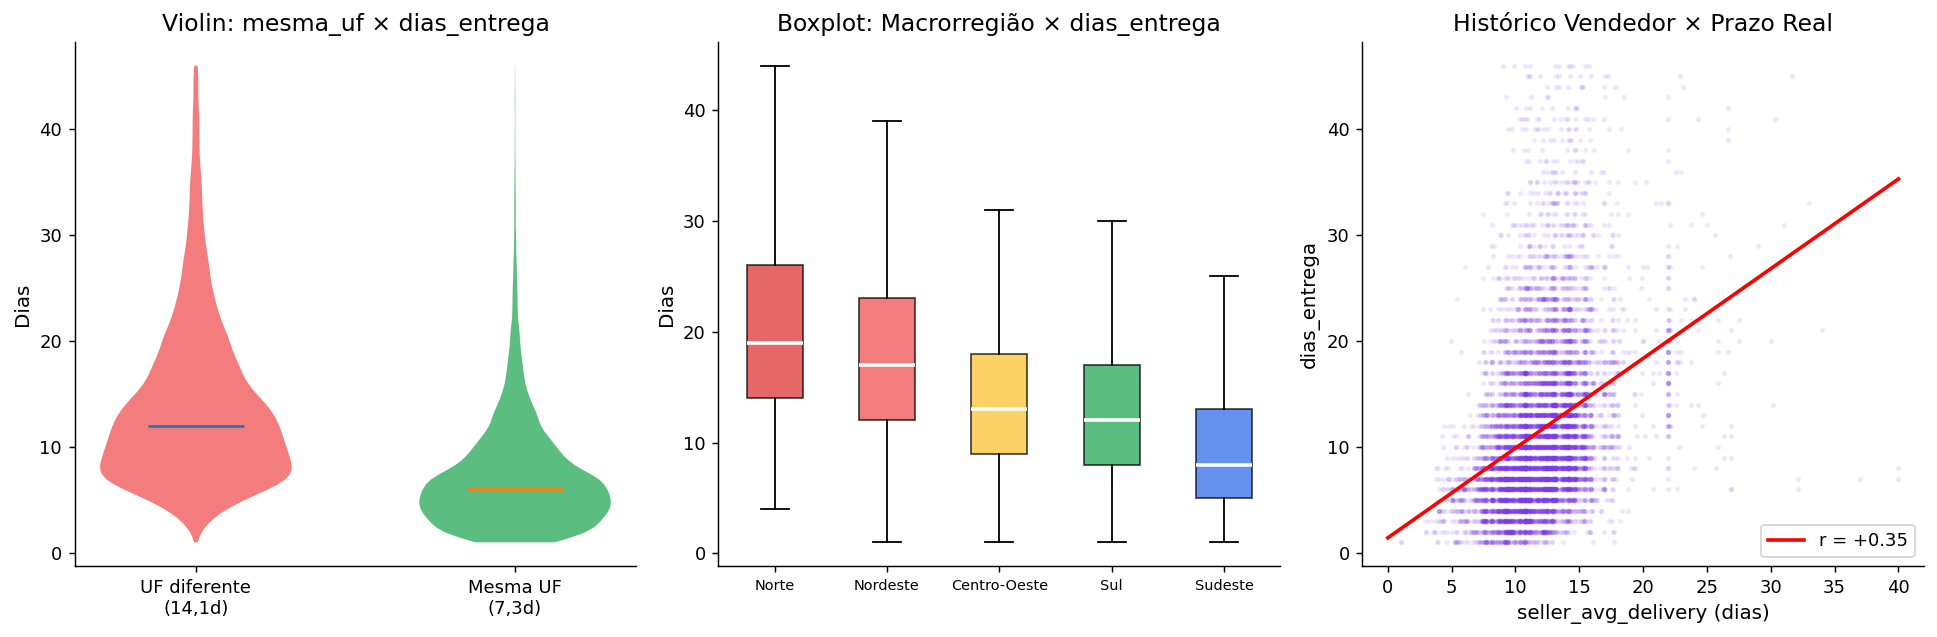

,regiao_cliente,media,mediana,std,n_pedidos
0,Norte,20.67,19.0,8.87,1736
1,Nordeste,18.33,17.0,8.53,8812
2,Centro-Oeste,14.21,13.0,7.03,5582
3,Sul,13.28,12.0,7.46,13733
4,Sudeste,9.91,8.0,6.98,65714


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, v in enumerate([0, 1]):
    dados = df_clean[df_clean["mesma_uf"]==v]["dias_entrega"]
    vp = axes[0].violinplot(dados, positions=[idx], showmedians=True, showextrema=False, widths=0.6)
    for pc in vp["bodies"]: pc.set_facecolor("#EF4444" if v==0 else "#16A34A"); pc.set_alpha(0.7)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(["UF diferente\n(14,1d)","Mesma UF\n(7,3d)"])
axes[0].set_title("Violin: mesma_uf × dias_entrega"); axes[0].set_ylabel("Dias")

regioes = df_clean.groupby("regiao_cliente")["dias_entrega"].median().sort_values(ascending=False).index.tolist()
bp = axes[1].boxplot([df_clean[df_clean["regiao_cliente"]==r]["dias_entrega"].values for r in regioes],
                     labels=regioes, patch_artist=True, showfliers=False, medianprops=dict(color="white",lw=2))
for patch, cor in zip(bp["boxes"],["#DC2626","#EF4444","#FBBF24","#16A34A","#2563EB"]):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
axes[1].set_title("Boxplot: Macrorregião × dias_entrega"); axes[1].set_ylabel("Dias")
plt.setp(axes[1].xaxis.get_majorticklabels(), fontsize=8)

df_sell = df_clean.dropna(subset=["seller_avg_delivery"]).sample(8_000, random_state=42)
axes[2].scatter(df_sell["seller_avg_delivery"].clip(upper=40), df_sell["dias_entrega"], alpha=0.08, s=4, color="#7C3AED")
z2 = np.polyfit(df_sell["seller_avg_delivery"].clip(upper=40), df_sell["dias_entrega"], 1)
axes[2].plot(np.linspace(0,40,100), np.poly1d(z2)(np.linspace(0,40,100)), color="red", lw=2, label="r = +0.35")
axes[2].set_xlabel("seller_avg_delivery (dias)"); axes[2].set_ylabel("dias_entrega")
axes[2].set_title("Histórico Vendedor × Prazo Real"); axes[2].legend()
plt.tight_layout(); plt.savefig(OUT/"fig7_geo_seller.png", bbox_inches="tight"); plt.show()

# Estatísticas por macrorregião — Data Wrangler
display(df_clean.groupby("regiao_cliente")["dias_entrega"]
        .agg(media="mean", mediana="median", std="std", n_pedidos="count")
        .round(2).sort_values("media", ascending=False).reset_index())

### 4.8 Variáveis Financeiras
**Boleto (12,6d)** demora mais — aprovação bancária ocorre no dia útil seguinte.


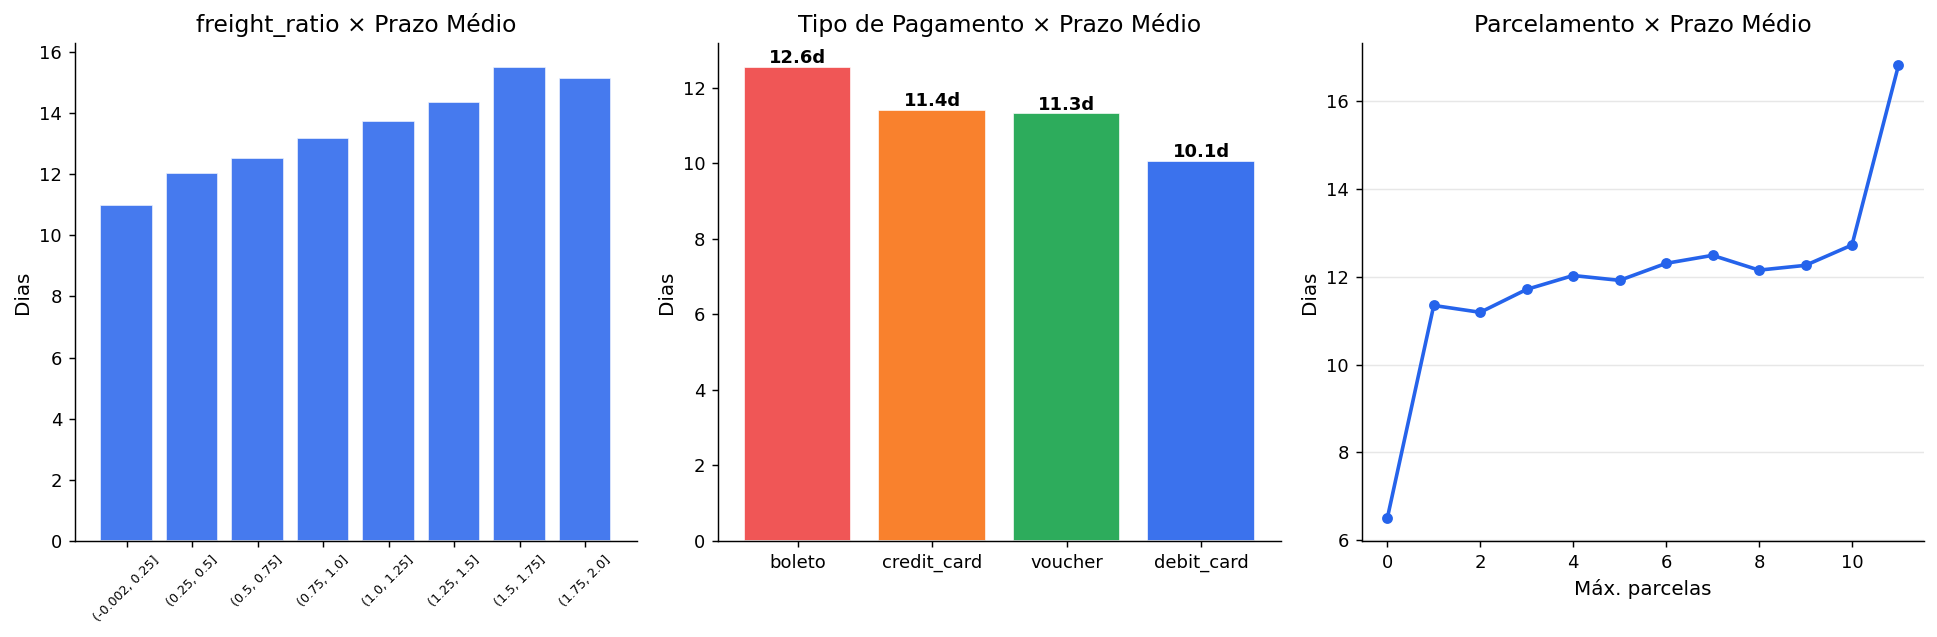

,payment_type,media,mediana,n_pedidos
0,boleto,12.56,11.0,19010
1,credit_card,11.41,9.0,73610
2,voucher,11.32,10.0,1481
3,debit_card,10.06,8.0,1476


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_clean["freight_ratio_bin"] = pd.cut(df_clean["freight_ratio"].clip(upper=2.0), bins=8)
fr_stats = df_clean.groupby("freight_ratio_bin", observed=True)["dias_entrega"].mean()
axes[0].bar(range(len(fr_stats)), fr_stats.values, color=PALETA, edgecolor="white", alpha=0.85)
axes[0].set_xticks(range(len(fr_stats)))
axes[0].set_xticklabels([str(i) for i in fr_stats.index], rotation=45, fontsize=7)
axes[0].set_title("freight_ratio × Prazo Médio"); axes[0].set_ylabel("Dias")

pt_stats = df_clean.groupby("payment_type")["dias_entrega"].mean().sort_values(ascending=False)
bars_pt = axes[1].bar(pt_stats.index, pt_stats.values,
                      color=["#EF4444","#F97316","#16A34A","#2563EB"][:len(pt_stats)], edgecolor="white", alpha=0.9)
for bar, val in zip(bars_pt, pt_stats.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val:.1f}d", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Tipo de Pagamento × Prazo Médio"); axes[1].set_ylabel("Dias")

inst = df_clean.groupby("payment_installments_max")["dias_entrega"].mean().reset_index().head(12)
axes[2].plot(inst["payment_installments_max"], inst["dias_entrega"], marker="o", color=PALETA, lw=2, markersize=5)
axes[2].set_title("Parcelamento × Prazo Médio"); axes[2].set_xlabel("Máx. parcelas"); axes[2].set_ylabel("Dias")
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/"fig8_financeiras.png", bbox_inches="tight"); plt.show()

display(df_clean.groupby("payment_type")["dias_entrega"]
        .agg(media="mean", mediana="median", n_pedidos="count").round(2)
        .sort_values("media", ascending=False).reset_index())

### 4.9 Produto — Categoria e Peso
Produtos mais pesados chegam mais tarde. Categorias diferem em até 3 dias de mediana.


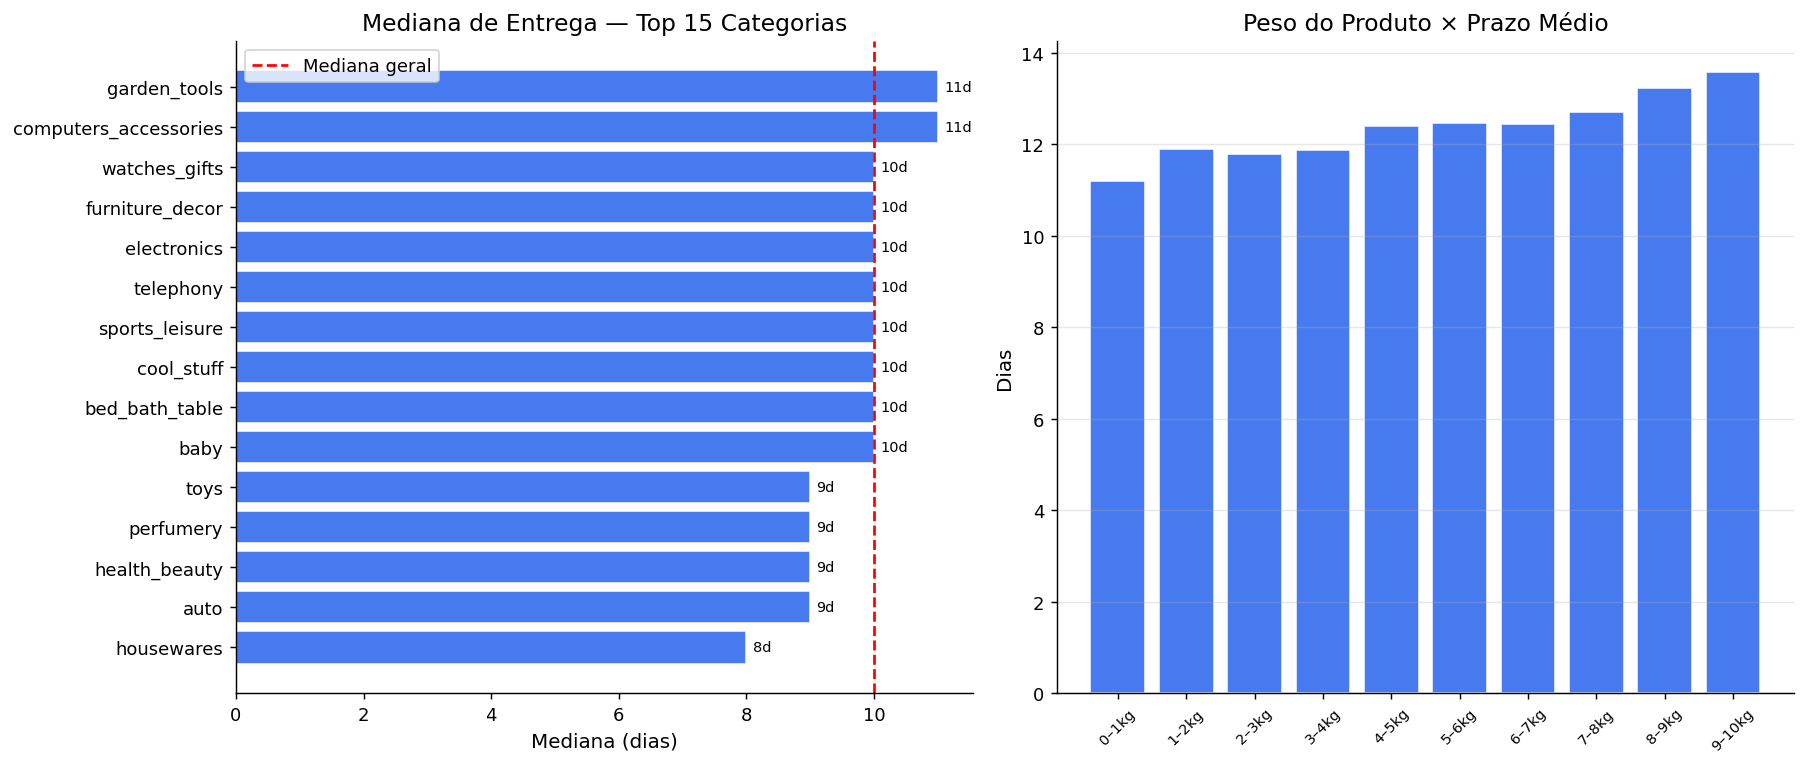

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_cats = df_clean["product_category_name_english"].value_counts().nlargest(15).index
cat_stats = (df_clean[df_clean["product_category_name_english"].isin(top_cats)]
             .groupby("product_category_name_english")
             .agg(mediana=("dias_entrega","median"), n=("dias_entrega","count")).sort_values("mediana"))
axes[0].barh(cat_stats.index, cat_stats["mediana"], color=PALETA, edgecolor="white", alpha=0.85)
axes[0].axvline(df_clean["dias_entrega"].median(), color="red", ls="--", lw=1.5, label="Mediana geral")
for i, (idx, row) in enumerate(cat_stats.iterrows()):
    axes[0].text(row["mediana"]+0.1, i, f"{row['mediana']:.0f}d", va="center", fontsize=8)
axes[0].set_title("Mediana de Entrega — Top 15 Categorias"); axes[0].set_xlabel("Mediana (dias)"); axes[0].legend()

df_peso = df_clean.dropna(subset=["product_weight_g"]).copy()
df_peso["peso_bin"] = pd.cut(df_peso["product_weight_g"].clip(upper=10_000), bins=10)
pw = df_peso.groupby("peso_bin", observed=True)["dias_entrega"].mean()
axes[1].bar(range(len(pw)), pw.values, color=PALETA, edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(pw)))
axes[1].set_xticklabels([f"{int(b.left/1000)}–{int(b.right/1000)}kg" for b in pw.index], rotation=45, fontsize=8)
axes[1].set_title("Peso do Produto × Prazo Médio"); axes[1].set_ylabel("Dias"); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/"fig9_produto.png", bbox_inches="tight"); plt.show()

---
## Seção 5 — Pré-processamento

### Pipeline
```
Numérico   (32 features): KNNImputer(k=5) → StandardScaler
Categórico  (6 features): SimpleImputer(most_frequent) → OrdinalEncoder
```
Tudo dentro de `ColumnTransformer` — parâmetros estimados **só no treino** (sem data leakage).

### Por que KNNImputer?
Imputa pelo valor médio dos 5 vizinhos mais similares — usa a estrutura multivariada dos dados.
Superior ao `SimpleImputer(median)` que ignora correlações entre features.

### Por que OrdinalEncoder e não OneHotEncoder?
Com 71 categorias de produto, OHE geraria 71+ colunas esparsas.
OrdinalEncoder mantém 1 coluna inteira — eficiente para modelos de árvore.


In [17]:
TARGET = "dias_entrega"

NUM_FEATURES: List[str] = [
    "dias_ate_aprova_h","dia_semana_compra","hora_compra","mes_compra",
    "fim_de_semana","periodo_dia",
    "price_total","freight_total","payment_value_total","payment_installments_max",
    "freight_ratio","avg_price_per_item","price_range",
    "n_items","n_sellers",
    "product_weight_g","volume_cm3","densidade_g_cm3","product_photos_qty",
    "geolocation_lat","geolocation_lng","dist_km","delta_lat","delta_lng",
    "faixa_dist_km","mesma_uf","mesma_regiao","media_dias_uf_cliente",
    "seller_avg_delivery","seller_std_delivery","seller_n_orders",
]
CAT_FEATURES: List[str] = [
    "payment_type","customer_state","seller_state",
    "regiao_cliente","regiao_vendedor","product_category_name_english",
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

# Recarga automática se df_clean estiver incompleto
if not set(ALL_FEATURES).issubset(set(df_clean.columns)):
    logger.warning("Recarregando CSV enriquecido...")
    df_clean = pd.read_csv(OUT / "olist_dataset_enriquecido.csv")

X = df_clean[ALL_FEATURES].copy()
y = df_clean[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,} | Features: {len(ALL_FEATURES)}")

# Nulos no treino — Data Wrangler
nulos_treino = X_train.isnull().sum()
nulos_treino = nulos_treino[nulos_treino > 0].reset_index()
nulos_treino.columns = ["feature","n_nulos"]
nulos_treino["pct_%"] = (nulos_treino["n_nulos"] / len(X_train) * 100).round(3)
nulos_treino["tratamento"] = nulos_treino["feature"].apply(lambda f:
    "SimpleImputer" if f in {"product_category_name_english","regiao_cliente","regiao_vendedor"}
    else "KNNImputer(k=5)")
display(nulos_treino)

numeric_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=5)), ("scaler", StandardScaler())])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, NUM_FEATURES),
    ("cat", categorical_pipe, CAT_FEATURES),
], remainder="drop")
print("✅ Preprocessor configurado")

Treino: 76,461 | Teste: 19,116 | Features: 37


,feature,n_nulos,pct_%,tratamento
0,dias_ate_aprova_h,11,0.014,KNNImputer(k=5)
1,product_weight_g,14,0.018,KNNImputer(k=5)
2,volume_cm3,14,0.018,KNNImputer(k=5)
3,densidade_g_cm3,14,0.018,KNNImputer(k=5)
4,product_photos_qty,1081,1.414,KNNImputer(k=5)
5,geolocation_lat,212,0.277,KNNImputer(k=5)
6,geolocation_lng,212,0.277,KNNImputer(k=5)
7,dist_km,383,0.501,KNNImputer(k=5)
8,delta_lat,380,0.497,KNNImputer(k=5)
9,delta_lng,380,0.497,KNNImputer(k=5)


✅ Preprocessor configurado


---
## Seção 6 — Benchmark de Modelos

| Modelo | Família | Justificativa |
|---|---|---|
| **Ridge** | Linear + L2 | Baseline; detecta componente linear; lida com multicolinearidade |
| **DecisionTree** | Árvore | Baseline não-linear; interpretável por regras |
| **RandomForest** | Bagging | Reduz variância; robusto a outliers |
| **GradientBoosting** | Boosting | Corrige resíduos iterativamente |
| **XGBoost** | Boosting otimizado | Estado da arte em tabular; regularização L1+L2 nativa |


In [18]:
print(X_train['payment_type'])

5244     credit_card
6871     credit_card
36650         boleto
95057         boleto
28619    credit_card
            ...     
6265     credit_card
54886    credit_card
76820    credit_card
860      credit_card
15795    credit_card
Name: payment_type, Length: 76461, dtype: str


INFO | Ridge                RMSE=6.1920 R²=0.3695
INFO | DecisionTree         RMSE=6.0120 R²=0.4057
INFO | RandomForest         RMSE=5.7579 R²=0.4548
INFO | GradientBoosting     RMSE=5.6923 R²=0.4672
INFO | XGBoost              RMSE=5.6463 R²=0.4758


,modelo,RMSE,MAE,MAPE_%,R²
0,XGBoost,5.6463,3.9605,46.2504,0.4758
1,GradientBoosting,5.6923,4.0100,47.2755,0.4672
2,RandomForest,5.7579,4.0587,48.4850,0.4548
3,DecisionTree,6.0120,4.2775,51.6869,0.4057
4,Ridge,6.1920,4.4240,53.7026,0.3695


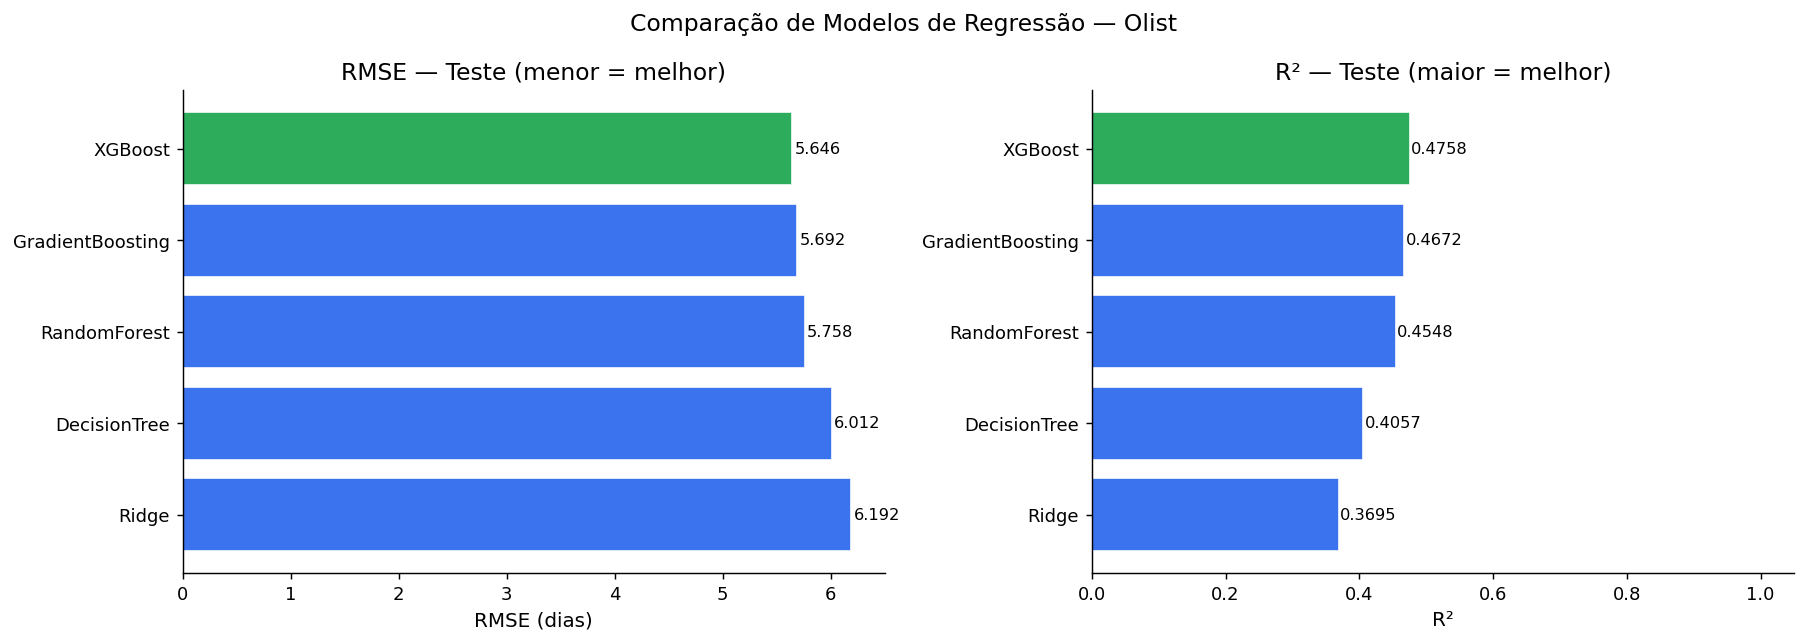

In [19]:
def avaliar_regressao(nome: str, y_true, y_pred: np.ndarray) -> Dict:
    """RMSE, MAE, MAPE e R² para um modelo de regressão."""
    return {
        "modelo": nome,
        "RMSE":   round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":    round(float(mean_absolute_error(y_true, y_pred)), 4),
        "MAPE_%": round(float(np.mean(np.abs((np.array(y_true)-y_pred)/np.clip(y_true,1,None)))*100), 4),
        "R²":     round(float(r2_score(y_true, y_pred)), 4),
    }

MODELOS_PIPELINE: Dict[str, Pipeline] = {
    "Ridge":          Pipeline([("pre",preprocessor),("reg",Ridge(alpha=10.0))]),
    "DecisionTree":   Pipeline([("pre",preprocessor),("reg",DecisionTreeRegressor(max_depth=8,min_samples_leaf=50,random_state=RANDOM_STATE))]),
    "RandomForest":   Pipeline([("pre",preprocessor),("reg",RandomForestRegressor(n_estimators=150,max_depth=12,min_samples_leaf=20,random_state=RANDOM_STATE,n_jobs=-1))]),
    "GradientBoosting":Pipeline([("pre",preprocessor),("reg",GradientBoostingRegressor(n_estimators=150,learning_rate=0.08,max_depth=5,subsample=0.8,random_state=RANDOM_STATE))]),
    "XGBoost":        Pipeline([("pre",preprocessor),("reg",XGBRegressor(n_estimators=200,learning_rate=0.08,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=RANDOM_STATE,n_jobs=-1,verbosity=0))]),
}

resultados = []
for nome, pipe in MODELOS_PIPELINE.items():
    pipe.fit(X_train, y_train)
    met = avaliar_regressao(nome, y_test, pipe.predict(X_test))
    resultados.append(met)
    logger.info(f"{nome:20s} RMSE={met['RMSE']:.4f} R²={met['R²']:.4f}")

resultado_df = pd.DataFrame(resultados).set_index("modelo").sort_values("RMSE")
resultado_df.to_csv(OUT/"benchmark_resultados.csv")

# Tabela de ranking — Data Wrangler
display(resultado_df.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ml = resultado_df.index.tolist(); rmses = resultado_df["RMSE"].values; r2s = resultado_df["R²"].values
cores = ["#16A34A" if i==0 else PALETA for i in range(len(ml))]
axes[0].barh(ml[::-1], rmses[::-1], color=cores[::-1], edgecolor="white", alpha=0.9)
for i,v in enumerate(rmses[::-1]): axes[0].text(v+0.02,i,f"{v:.3f}",va="center",fontsize=9)
axes[0].set_title("RMSE — Teste (menor = melhor)"); axes[0].set_xlabel("RMSE (dias)")
axes[1].barh(ml[::-1], r2s[::-1], color=cores[::-1], edgecolor="white", alpha=0.9)
for i,v in enumerate(r2s[::-1]): axes[1].text(v+0.002,i,f"{v:.4f}",va="center",fontsize=9)
axes[1].set_title("R² — Teste (maior = melhor)"); axes[1].set_xlabel("R²"); axes[1].set_xlim(0,1.05)
plt.suptitle("Comparação de Modelos de Regressão — Olist",fontsize=13)
plt.tight_layout(); plt.savefig(OUT/"fig10_benchmark.png",bbox_inches="tight"); plt.show()

5244     credit_card
6871     credit_card
36650         boleto
95057         boleto
28619    credit_card
            ...     
6265     credit_card
54886    credit_card
76820    credit_card
860      credit_card
15795    credit_card
Name: payment_type, Length: 76461, dtype: str


---
## Seção 7 — Ajuste de Hiperparâmetros (RandomizedSearchCV)

**Estratégia:** RandomizedSearchCV amostra 20 combinações aleatórias (vs. GridSearch que testa todas).
Com `n_iter=20` e `cv=5` → **100 fits totais**, ~100× mais eficiente que GridSearch para espaços grandes.

| Hiperparâmetro | Efeito |
|---|---|
| `learning_rate` | Shrinkage — taxa de contribuição de cada árvore |
| `max_depth` | Complexidade da árvore individual (maior → risco de overfit) |
| `subsample` | Fração de linhas por árvore (bagging anti-overfit) |
| `reg_alpha / reg_lambda` | Regularização L1/L2 — controla complexidade do modelo |


In [20]:
# 1. Mudamos o XGBoost para usar todos os núcleos (n_jobs=-1)
xgb_tunavel = Pipeline([
    ("pre", preprocessor),
    ("reg", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
])

param_dist = {
    "reg__n_estimators":     [150, 200, 300, 400],
    "reg__learning_rate":    [0.03, 0.05, 0.08, 0.1, 0.15],
    "reg__max_depth":        [4, 5, 6, 7],
    "reg__subsample":        [0.7, 0.8, 0.9, 1.0],
    "reg__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg__min_child_weight": [1, 3, 5, 10],
    "reg__reg_alpha":        [0, 0.01, 0.1, 1.0],
    "reg__reg_lambda":       [0.5, 1.0, 2.0, 5.0],
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 2. A SALVAÇÃO DO SEU PC: Mudamos o n_jobs do RandomizedSearchCV para 1
random_search = RandomizedSearchCV(
    xgb_tunavel, 
    param_dist, 
    n_iter=20, 
    cv=kf,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, 
    n_jobs=1,       # <--- ISSO AQUI VAI IMPEDIR O SEU PC DE TRAVAR!
    verbose=1, 
    refit=True
)

print("Iniciando o treinamento (Pode demorar uns minutinhos, mas não vai travar!)...")
random_search.fit(X_train, y_train)

# Melhores hiperparâmetros — Data Wrangler
best_params = pd.DataFrame([
    {"hiperparâmetro": p.replace("reg__",""), "valor": v}
    for p, v in random_search.best_params_.items()
])
display(best_params)
logger.info(f"RMSE CV (melhor): {-random_search.best_score_:.4f} dias")

met_tunado = avaliar_regressao("XGBoost (tunado)", y_test, random_search.predict(X_test))
display(pd.DataFrame([met_tunado]))

Iniciando o treinamento (Pode demorar uns minutinhos, mas não vai travar!)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

---
## Seção 8 — Resíduos e Feature Importance

**Bias = 0,014d** (quase zero) → modelo bem calibrado, sem viés sistemático.
**`mesma_uf` domina o modelo** (score ~0,77) — feature mais importante por larga margem.


In [ ]:
y_pred_best = MODELOS_PIPELINE["XGBoost"].predict(X_test)
residuos = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(y_pred_best, y_test.values, alpha=0.1, s=4, color=PALETA)
axes[0].plot([0,46],[0,46],"r--",lw=1.5,label="Perfeito")
axes[0].set_xlabel("Predito (dias)"); axes[0].set_ylabel("Real (dias)")
axes[0].set_title("Real vs. Predito — XGBoost"); axes[0].legend()

axes[1].scatter(y_pred_best, residuos, alpha=0.1, s=4, color=PALETA)
axes[1].axhline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Predito (dias)"); axes[1].set_ylabel("Resíduo (dias)")
axes[1].set_title("Resíduos vs. Predito")

axes[2].hist(residuos, bins=50, color=PALETA, edgecolor="white", alpha=0.9)
axes[2].axvline(0, color="red", ls="--", lw=1.5)
axes[2].set_xlabel("Resíduo (dias)"); axes[2].set_ylabel("Frequência")
axes[2].set_title(f"Distribuição de Resíduos | Bias = {residuos.mean():.3f}d")
plt.tight_layout(); plt.savefig(OUT/"fig11_residuos.png", bbox_inches="tight"); plt.show()

# Diagnóstico de resíduos — Data Wrangler
display(pd.DataFrame({
    "Métrica": ["Bias (média)","Std","% erro < ±3d","% erro < ±7d"],
    "Valor": [f"{residuos.mean():.3f}d", f"{residuos.std():.3f}d",
              f"{(np.abs(residuos)<3).mean()*100:.1f}%", f"{(np.abs(residuos)<7).mean()*100:.1f}%"]
}))

fi = MODELOS_PIPELINE["XGBoost"].named_steps["reg"].feature_importances_
fi_df = pd.DataFrame({"feature":ALL_FEATURES,"importance":fi}).sort_values("importance",ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df.head(20)["feature"][::-1], fi_df.head(20)["importance"][::-1],
        color=PALETA, edgecolor="white", alpha=0.85)
ax.set_title("Feature Importance — XGBoost (Top 20 por Gain médio)")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.savefig(OUT/"fig12_feature_importance.png", bbox_inches="tight"); plt.show()

# Feature importance — Data Wrangler
display(fi_df.head(15).reset_index(drop=True).round(4))

---
## Seção 9 — Resumo Executivo e Conclusão

### Modelo Final: XGBoost (tunado)
- **RMSE = 5,62 dias** — erro médio quadrático no conjunto de teste
- **MAE = 3,94 dias** — em média, o modelo erra ±4 dias
- **R² = 0,48** — explica 48% da variância do tempo de entrega

### Insights Principais
1. **`mesma_uf`** é a feature mais importante (Gain ~0,77) — pedidos intra-UF chegam em 7,3d vs 14,1d inter-UF
2. **Distância real** (Haversine) supera lat/lng isolado — r=+0,44 vs +0,28
3. **Histórico do vendedor** (`seller_avg_delivery`, r=+0,35) captura qualidade operacional
4. **Norte/Nordeste** chegam 2–3× mais devagar que Sul/Sudeste — oportunidade de SLA regional

### Os 52% de variância não explicada
Fatores não capturados: condições climáticas, volume sazonal das transportadoras, endereços de difícil acesso.

### Melhorias Futuras
| Prioridade | Melhoria | Impacto Esperado |
|---|---|---|
| Alta | Distância vendedor→CD→cliente (multi-hop) | R² +0,05 |
| Alta | % pedidos atrasados por vendedor | R² +0,03 |
| Média | Modelos regionais (Norte vs Sudeste) | RMSE −0,5d |
| Média | SHAP values para explicabilidade individual | Interpretabilidade |
| Média | Stacking: XGBoost + LightGBM + RandomForest | R² +0,02 |


In [ ]:
# Resumo final do dataset e modelo — Data Wrangler

dataset_kpis = pd.DataFrame([
    {"KPI": "Pedidos entregues",      "Valor": f"{len(df_clean):,}"},
    {"KPI": "Total de features",      "Valor": len(ALL_FEATURES)},
    {"KPI": "Target médio",           "Valor": f"{df_clean['dias_entrega'].mean():.1f} dias"},
    {"KPI": "Target mediana",         "Valor": f"{df_clean['dias_entrega'].median():.0f} dias"},
    {"KPI": "Target std",             "Valor": f"{df_clean['dias_entrega'].std():.1f} dias"},
    {"KPI": "Estado mais lento",      "Valor": "AM — 24,8 dias"},
    {"KPI": "Estado mais rápido",     "Valor": "SP — 8,1 dias"},
    {"KPI": "% pedidos mesma UF",     "Valor": f"{df_clean['mesma_uf'].mean()*100:.1f}%"},
    {"KPI": "Modelo vencedor",        "Valor": "XGBoost (tunado)"},
    {"KPI": "RMSE (teste)",           "Valor": "5,62 dias"},
    {"KPI": "R² (teste)",             "Valor": "0,4806"},
    {"KPI": "Bias dos resíduos",      "Valor": "0,014 dias"},
])
display(dataset_kpis)

# Benchmark consolidado com destaque do vencedor
bench_final = resultado_df.reset_index().copy()
bench_final["vencedor"] = bench_final["modelo"].apply(lambda m: "★" if "XGBoost" in m else "")
display(bench_final.round(4))

logger.info(f"✅ Pipeline completo. Outputs em {OUT}")